# 📊**Gaussian Naive Bayes**

Este modelo é ajustado encontrando a **média** e o **desvio padrão** de cada classe. Aqui será trabalhada uma base e dados sintética e já limpa, pois o foco será o treino do modelo em si, que trará variáveis como: horas de estudo, nota anterior, faltas e aprovado. As três primeiras variáveis tentarão predizer a última, ou seja, com base na quantidade de horas de estudo, no valor da nota anterior e na quantidade de faltas vamos descobrir se um aluno tem mais probabilidade de ser aprovado ou não. 

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

gaussian = pd.read_csv('../data/base_gaussian_nb.csv')

### **Base de dados**

In [2]:
gaussian.head(5)

,ID,Horas_Estudo,Nota_Anterior,Faltas,Aprovado
0,1,5.5,7.0,9,Não
1,2,3.1,5.2,5,Não
2,3,6.4,6.2,6,Sim
3,4,6.7,7.3,4,Sim
4,5,1.5,5.2,9,Não


In [3]:
gaussian.shape

(150, 5)

In [4]:
#informações básicas
gaussian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             150 non-null    int64  
 1   Horas_Estudo   150 non-null    float64
 2   Nota_Anterior  150 non-null    float64
 3   Faltas         150 non-null    int64  
 4   Aprovado       150 non-null    object 
dtypes: float64(2), int64(2), object(1)
memory usage: 6.0+ KB


In [6]:
#informações estatísticas básicas
gaussian.describe()

,ID,Horas_Estudo,Nota_Anterior,Faltas
count,150.000000,150.000000,150.000000,150.00000
mean,75.500000,4.902667,6.830667,6.12000
std,43.445368,1.519711,1.114453,2.50883
min,1.000000,1.200000,4.300000,0.00000
25%,38.250000,3.825000,6.200000,5.00000
50%,75.500000,4.950000,6.900000,6.00000
75%,112.750000,5.975000,7.400000,8.00000
max,150.000000,9.500000,9.800000,12.00000


In [8]:
# atributo meta 
gaussian['Aprovado'].value_counts()

Aprovado
Não    75
Sim    75
Name: count, dtype: int64

In [9]:
gaussian.columns

Index(['ID', 'Horas_Estudo', 'Nota_Anterior', 'Faltas', 'Aprovado'], dtype='object')

### **Entendo como as características se comportam dentro de cada atributo**

In [8]:
gaussian.groupby('Aprovado').mean(numeric_only=True)

,ID,Horas_Estudo,Nota_Anterior,Faltas
Aprovado,,,,
Não,80.16,3.866667,6.158667,7.60
Sim,70.84,5.938667,7.502667,4.64


In [9]:
gaussian.groupby('Aprovado').std(numeric_only=True)

,ID,Horas_Estudo,Nota_Anterior,Faltas
Aprovado,,,,
Não,45.723328,1.074311,0.904806,1.895942
Sim,40.815021,1.149135,0.875642,2.153815


* **OBS.:** no modelo gaussiano a média e o desvio padrão são o que definirá qual será a altura e a largura da linha no gráfico, respectivamente. Por isso são as únicas características analisadas nesse tópico.

### **Definição dos atributos e do atributo-meta**

In [10]:
X = gaussian.drop(columns=['ID', 'Aprovado'])
y = gaussian['Aprovado']

In [11]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y #tenta manter a mesma proporção entre o "sim" e o "não" nos conjuntos de treino e teste
)

In [12]:
y_train.value_counts(normalize=True)

Aprovado
Não    0.5
Sim    0.5
Name: proportion, dtype: float64

* Agrupando os alunos de acordo com o atributo-meta vemos que houve uma leve modificação nos valores das médias e desvios padrões para cada atributo. Esses serão os valores utilizados como base para a construção da visualização.

In [13]:
X_train.groupby(y_train).mean()

,Horas_Estudo,Nota_Anterior,Faltas
Aprovado,,,
Não,3.896667,6.248333,7.633333
Sim,6.008333,7.540000,4.616667


In [15]:
X_train.groupby(y_train).var()

,Horas_Estudo,Nota_Anterior,Faltas
Aprovado,,,
Não,0.990158,0.805251,3.558192
Sim,1.437387,0.800746,4.511582


In [16]:
X_train.groupby(y_train).std()

,Horas_Estudo,Nota_Anterior,Faltas
Aprovado,,,
Não,0.995067,0.897358,1.886317
Sim,1.198911,0.894844,2.124048


### **Treinando o Gaussian Naive Bayes**

In [17]:
from sklearn.naive_bayes import GaussianNB

gaussian_model = GaussianNB()

gaussian_model.fit(X_train, y_train)

GaussianNB()

In [19]:
# Probabilidade a priori (inicial).

gaussian_model.class_prior_

array([0.5, 0.5])

* Tanto para o valor "Não" quanto para o valor "Sim" a probabilidade inicial é de 50%.

In [20]:
# médias aprendidas 
gaussian_model.theta_

array([[3.89666667, 6.24833333, 7.63333333],
       [6.00833333, 7.54      , 4.61666667]])

In [21]:
# variâncias aprendidas 
gaussian_model.var_

array([[0.97365556, 0.79183056, 3.4988889 ],
       [1.41343056, 0.78740001, 4.4363889 ]])

### **Fazendo previsões**

In [24]:
y_pred = gaussian_model.predict(X_test)

In [ ]:
result = pd.DataFrame ({
    'Real': y_test,
    'Previsto': y_pred
})

result.head(10)

,Real,Previsto
111,Sim,Sim
128,Não,Sim
147,Sim,Não
44,Não,Não
43,Sim,Sim
144,Não,Não
77,Sim,Sim
112,Não,Não
52,Não,Não
46,Sim,Sim


* Estes valores serão utlizados na matriz de confusão.

### **Matriz de Confusão**

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test, 
    y_pred, 
    labels=['Não', 'Sim']
)

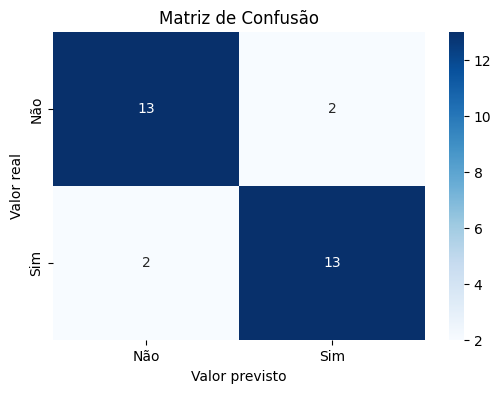

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Não', 'Sim'], 
    yticklabels=['Não', 'Sim']
)

plt.xlabel('Valor previsto')
plt.ylabel('Valor real')
plt.title('Matriz de Confusão')

plt.show()

* O valores na diagonal, destacados de azul, mostram os resultados que foram previstos pelo modelo e bateram com o resultado esperado, ou seja, em termos estatísticos são os _True Negatives (TN)_ e os _True Positive (TP)_.

* Apenas para fins didáticos colocarei as principais métricas que podem ser avaliadas aqui.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred, pos_label="Sim"))

print("Recall:", recall_score(y_test, y_pred, pos_label="Sim"))

Accuracy: 0.8666666666666667
Precision: 0.8666666666666667
Recall: 0.8666666666666667
F1-score: 0.8666666666666667


* **Accuracy** - Proporção de todas as classificações que estavam corretas, sejam elas positivas ou negativas. 

$$Accuracy = \frac{\text{Classificações corretas}}{\text{Total de Classificações}}=\frac{TP+TN}{TP+TN+FP+FN}$$
<br>

* **Precision** - Proporção de todas as classificações positivas do modelo que são realmente positivas. 

$$Precision= \frac{\text{Todas classificações positivas}}{\text{Tudo que foi classificado como positivo}}=\frac{TP}{TP+FP}$$
<br>

* **Recall** - Proporção de todos os positivos reais que foram classificados corretamente como positivos.

$$Recall= \frac{\text{Classificações corretas de valores positivos}}{\text{Total de classificações positivas}}=\frac{TP}{TP+FN}$$


### **Gráfico de Gauss**

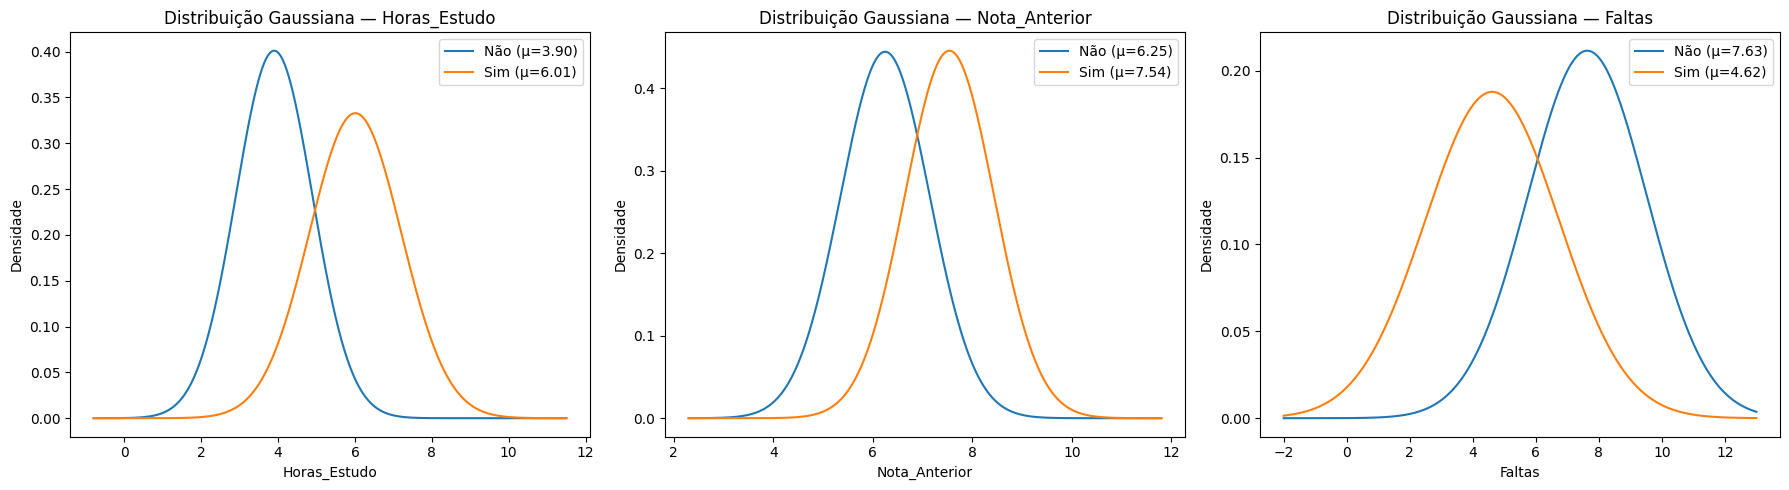

In [ ]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, X_train.columns):

    # intervalo usando todos os dados da variável
    minimo = X_train[feature].min() - 2
    maximo = X_train[feature].max() + 2

    x = np.linspace(minimo, maximo, 1000)

    for classe in ["Não", "Sim"]:

        dados = X_train[y_train == classe][feature]

        media = dados.mean()
        variancia = dados.var()
        desvio_padrao = np.sqrt(variancia)

        y = norm.pdf(x, media, desvio_padrao)

        ax.plot(
            x,
            y,
            label=f"{classe} (μ={media:.2f})"
        )

    ax.set_title(f"Distribuição Gaussiana — {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidade")
    ax.legend()

plt.tight_layout()
plt.show()

### **Conclusão** 

A análise visual das distribuições gaussianas indica que as características apresentam comportamentos diferentes entre as classes "Sim" e "Não". Alunos aprovados tendem a apresentar **maior número de horas de estudo** e **maior nota anterior**, enquanto alunos não aprovados tendem a apresentar **maior número de faltas**. Embora exista sobreposição entre algumas distribuições, as diferenças entre suas médias sugerem que essas variáveis podem contribuir para a classificação realizada pelo modelo _Gaussian Naive Bayes_.